# 🛡️ Workshop 5.2: Intrusion Detection on CAN (Vehicle Network) Traffic

## 🎯 Learning Objectives
Upon completion of this notebook, you will be able to:
- **Load and inspect** a real-world automotive cybersecurity dataset
- **Preprocess and transform** raw CAN frames, including parsing hexadecimal payloads and fixing misaligned labels
- **Engineer meaningful numerical features** from raw CAN traffic data
- **Train a light weight machine learning classification model** for binary intrusion detection (normal vs.attack)
- **Evaluate model performance** using standard classification metrics such as accuracy, precision and recall
- **Interpret the model results**

## 📚 Prerequisites

Before running this notebook, you should be familiar with:

| Concept | Why It Matters Here |
|---|---|
| Python basics (loops, functions, lists) | Code structure throughout |
| Pandas DataFrames | Data loading, cleaning, and manipulation |
| NumPy arrays | Feature matrix construction |
| Binary classification concepts | Understanding what we are predicting |
| Basic ML workflow (train/test split) | Model development pipeline |
| Hexadecimal number system | CAN payloads are stored in hex |

**Software**
- Python 3.9+
- `numpy`, `pandas`, `scikit-learn`

> If you are running on Google Colab, these packages are usually pre-installed. If you run locally, install with:
> `pip install numpy pandas scikit-learn`

> 💡 **New to hex?** Hexadecimal (base-16) uses digits 0–9 and letters A–F. For example, `0xFF = 255` in decimal. Python's `int('ff', 16)` converts hex strings to integers.




## Part 1: Theoretical Background

### 1.1 What is the CAN Bus?
The **Controller Area Network (CAN)** is a communication standard developed by Bosch in the 1980s. It is the primary messaging backbone inside virtually every modern vehicle, allowing **Electronic Control Units (ECUs)** — the small embedded computers that control specific vehicle functions — to exchange data efficiently without a central host computer.

**Did You Know?** A typical modern vehicle has **70–100+ ECUs** all sharing the same CAN bus, sending thousands of messages per second.

 ---

 ### 1.2 Structure of a CAN Frame

Every CAN message (called a **frame**) follows this structure:

```
┌───────────────┬─────┬──────────────────────────────────┬──────┐
│  Timestamp    │ ID  │  Payload (DATA0 ... DATA7)       │ Flag │
│  (Unix epoch) │(hex)│  Up to 8 bytes of data           │ R/T  │
└───────────────┴─────┴──────────────────────────────────┴──────┘
```

| Field | Description |
|---|---|
| **Timestamp** | Unix timestamp — when the message was captured |
| **CAN_ID** | 11-bit identifier (hex) — identifies which ECU sent the message and its priority |
| **DLC** | Data Length Code — number of valid data bytes (1–8) |
| **DATA0–DATA7** | Up to 8 bytes of actual payload, in hexadecimal |
| **Flag** | Label: `R` = normal (Regular), `T` = attack (injected/Tampered) |

---

### 1.3 Why Is CAN Insecure?

CAN was mainly designed for **reliability and real-time performance**, not security. Its key vulnerabilities are:

- ❌ **No authentication**: Any node on the bus can send any message — there is no way to verify who sent it
- ❌ **No encryption**: All data is transmitted in plain text
- ❌ **Broadcast by design**: Every message is seen by all ECUs on the bus
- ❌ **Priority-based arbitration**: High-priority messages (low CAN IDs) can dominate the bus

---

### 1.4 Common CAN Bus Attack Types

| Attack Type | Description | Effect |
|---|---|---|
| **DoS (Denial of Service)** | Flood the bus with high-priority messages | Legitimate ECUs cannot communicate |
| **Spoofing / Masquerade** | Inject fake messages pretending to be a legitimate ECU | Can manipulate brakes, steering, engine |
| **Fuzzy Attack** | Send random/corrupted messages | Destabilize ECU behavior unpredictably |
| **Replay Attack** | Capture and retransmit recorded messages | Re-trigger past vehicle states |

---

### 1.5 Machine Learning for Intrusion Detection

An **Intrusion Detection System (IDS)** monitors CAN traffic and flags anomalous or malicious messages. ML-based IDS approaches work by:

1. **Learning normal patterns** of CAN traffic during benign operation
2. **Flagging deviations** from those patterns as potential attacks

The pipeline in this workshop follows a **supervised binary classification** approach:

```
Raw CAN CSV  →  Clean & Parse  →  Feature Engineering  →  Train/Test Split
                                                                  ↓
Evaluation  ←  Metrics  ←  Predict  ←  Random Forest Model  ←  Fit
```

## Part 2: Hands-On

### Step 1: Import necessary libraries

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

### Step 2: Load data

### Why We Need to Mount Google Drive

Google Colab runs in a temporary cloud environment — its local filesystem is **reset every session**. To access persistent files (like our CAN dataset), we mount Google Drive as if it were a local disk.

**After running the cell below:**
1. You will see a link prompting you to authorize Google Drive access
2. Click the link → select your Google account
3. Click `Continue` and `Ok` when prompted to complete mounting process
4. Your Drive will be accessible at `/content/drive/MyDrive/`

> 📁 **Required file location:** Make sure `DoS_dataset.csv` is uploaded to your Google Drive at:  
> `MyDrive/NAIRR Workshop/5.2/DoS_dataset.csv`

> 🔄 **If running locally (not Colab):** Skip this cell and update the file path in the next section directly to your local path, e.g., `df = pd.read_csv('./data/DoS_dataset.csv', names=columns)`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Understanding the Dataset Schema

We are working with the **[OTIDS / HCRL Car Hacking Dataset](https://www.kaggle.com/datasets/pranavjha24/car-hacking-dataset)**, specifically the **DoS (Denial-of-Service) attack subset**.

The CSV file has **no header row**, so we must manually assign column names:

```
Timestamp | CAN_ID | DLC | DATA0 | DATA1 | DATA2 | DATA3 | DATA4 | DATA5 | DATA6 | DATA7 | Flag
```

**Column descriptions:**

| Column | Type | Description |
|---|---|---|
| `Timestamp` | Float (Unix epoch) | Capture time in seconds since Jan 1, 1970 |
| `CAN_ID` | String (hex, e.g. `0316`) | Identifier of the message — determines sender and priority |
| `DLC` | Integer (1–8) | Data Length Code — how many data bytes are valid |
| `DATA0`–`DATA7` | String (hex byte, e.g. `ff`) | Payload bytes |
| `Flag` | String (`R` or `T`) | Ground truth label: `R` = Regular (normal), `T` = Tampered (attack) |

In [ ]:
# Define column names manually since the CSV has no header row
columns = ["Timestamp", "CAN_ID", "DLC", "DATA0", "DATA1", "DATA2", "DATA3", "DATA4", "DATA5", "DATA6", "DATA7", "Flag"]

### Loading the Dataset


In [ ]:
# read csv files
df_dos = pd.read_csv('/content/drive/MyDrive/NAIRR Workshop/5.2/DoS_dataset.csv', names=columns)
df_fuzzy = pd.read_csv('/content/drive/MyDrive/NAIRR Workshop/5.2/Fuzzy_dataset.csv', names=columns)
df_normal = pd.read_csv('/content/drive/MyDrive/NAIRR Workshop/5.2/normal_run_data.csv')

In [ ]:
# Know the size of the dataset
print(f"Shape of the DoS dataset: {df_dos.shape}")
print(f"Number of samples in the DoS dataset: {df_dos.shape[0]}")
print(f"Number of features in the DoS dataset: {df_dos.shape[1] - 1}")

Shape of the DoS dataset: (3665771, 12)
Number of samples in the DoS dataset: 3665771
Number of features in the DoS dataset: 11


In [ ]:
# Know the size of the dataset
print(f"Shape of the Fuzzy dataset: {df_fuzzy.shape}")
print(f"Number of samples in the Fuzzy dataset: {df_fuzzy.shape[0]}")
print(f"Number of features in the Fuzzy dataset: {df_fuzzy.shape[1] - 1}")

Shape of the Fuzzy dataset: (3838860, 12)
Number of samples in the Fuzzy dataset: 3838860
Number of features in the Fuzzy dataset: 11


In [ ]:
# Know the size of the dataset
print(f"Shape of the Normal dataset: {df_normal.shape}")
print(f"Number of samples in the Normal dataset: {df_normal.shape[0]}")
print(f"Number of features in the Normal dataset: {df_normal.shape[1] - 1}")

Shape of the Normal dataset: (988871, 12)
Number of samples in the Normal dataset: 988871
Number of features in the Normal dataset: 11


In [ ]:
# Inspect the first 5 rows
df_normal.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Flag
0,1.479121e+09,0350,8,05,28,84,66,6d,00,00,a2,0
1,1.479121e+09,02c0,8,14,00,00,00,00,00,00,00,0
2,1.479121e+09,0430,8,00,00,00,00,00,00,00,00,0
3,1.479121e+09,04b1,8,00,00,00,00,00,00,00,00,0
4,1.479121e+09,01f1,8,00,00,00,00,00,00,00,00,0


In [10]:
# Since number of records are close to 3.6 million, we can work with a subset of the data sample
df_dos = df_dos.sample(n=200000, random_state=42)
df_fuzzy = df_fuzzy.sample(n=200000, random_state=42)
df_normal = df_normal.sample(n=200000, random_state=42)

Replace the Flag column in `df_dos` with 1 and `df_fuzzy` with 2 respectively.

In [11]:
df_dos['Flag'] = 1
df_fuzzy['Flag'] = 2

Combine the 3 datasets

In [12]:
df = pd.concat([df_dos, df_fuzzy, df_normal], ignore_index=True)

print("Final dataset shape:", df.shape)
print(df['Flag'].value_counts())

Final dataset shape: (600000, 12)
Flag
1    200000
2    200000
0    200000
Name: count, dtype: int64


In [13]:
df.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Flag
0,1.478201e+09,02c0,8,14,00,00,00,00,00,00,00,1
1,1.478201e+09,0131,8,00,80,00,00,25,7f,09,6e,1
2,1.478201e+09,0316,8,05,23,30,0a,23,1f,00,6f,1
3,1.478200e+09,0260,8,1a,23,23,30,08,8e,6d,03,1
4,1.478201e+09,0440,8,ff,00,00,00,ff,dc,08,00,1


### Step 3: Data Cleaning and Preprocessing

### 3.1 Detecting a Known Parsing Problem

#### The Problem: Misaligned Labels

CAN messages with **fewer than 8 data bytes** (i.e., `DLC < 8`) are a common source of parsing errors. When a message has only 2 valid data bytes, the CSV looks like:

```
1.478198e+09, 05f0, 2, 01, 00, R, , , , , ,
```

Here, since `DLC = 2`, only `DATA0` and `DATA1` hold real values. The actual `Flag` label (`R`) was placed in `DATA2` instead of the `Flag` column — causing **column misalignment**.

This means:
- `DATA2` contains `"R"` (a string label, not a hex byte)
- `DATA3` through `DATA7` are also `NaN`

Let's confirm this by finding rows where `DATA*` column contains `R` or `T`:

In [14]:
# Build a list of the 8 data column names for convenience
data_cols = [f"DATA{i}" for i in range(8)]

# Convert all data columns to string type
# This ensures consistent handling whether values are integers, floats, or strings
for col in data_cols:
    df[col] = df[col].astype(str)

for col in data_cols:
    mask = df[col].isin(["R", "T"])           # Boolean mask: True where flag is misplaced
    #df.loc[mask, "Flag"] = df.loc[mask, col]  # Move the label to the Flag column
    #df.loc[mask, col] = "00"                  # Replace misplaced label with neutral hex "00"
    print(col, df[col].isin(["R", "T"]).sum())

DATA0 0
DATA1 0
DATA2 3525
DATA3 0
DATA4 0
DATA5 2824
DATA6 0
DATA7 0


### 3.2 Fixing the Misalignment

In [15]:
for col in data_cols:
    mask = df[col].isin(["R", "T"])           # Boolean mask: True where flag is misplaced
    df.loc[mask, col] = "00"                  # Replace misplaced label with neutral hex "00"
    print(col, df[col].isin(["R", "T"]).sum()) # Verify the fix

DATA0 0
DATA1 0
DATA2 0
DATA3 0
DATA4 0
DATA5 0
DATA6 0
DATA7 0


### 3.3 Check for missing values

After the misalignment fix, remaining `NaN` values in DATA columns come from messages where `DLC < 8` (i.e., fewer than 8 valid payload bytes). For example, a message with `DLC = 3` only has `DATA0`, `DATA1`, `DATA2` defined — `DATA3` through `DATA7` are genuinely empty.

**Treatment strategy:** Replace `NaN` with `"00"` (hex for zero). This is a common convention — unused payload bytes are treated as zero-padding.

In [16]:
df[data_cols] = df[data_cols].fillna("00")

In [17]:
# Final Check for missing values
print([df.isna().sum()] if df.isna().sum().sum() > 0 else "No missing values in the dataset")

No missing values in the dataset


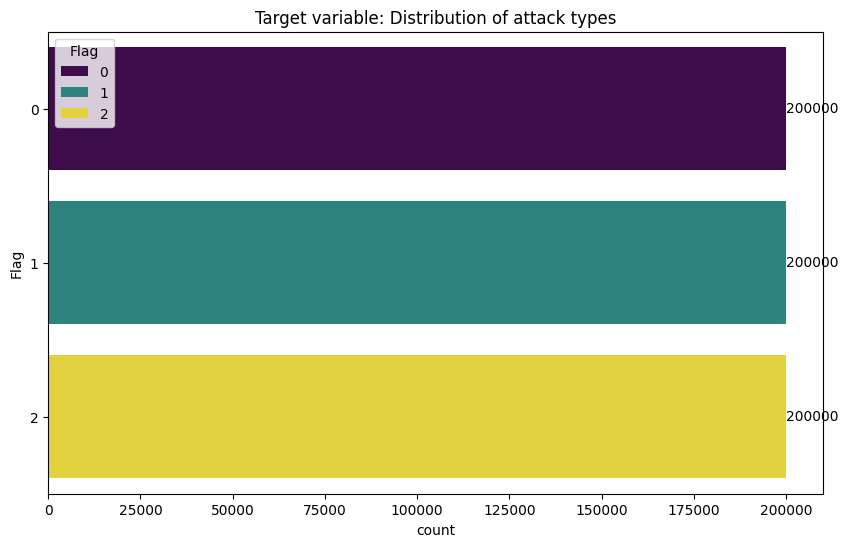

Class distribution:
1: 200000 (33.33%)
2: 200000 (33.33%)
0: 200000 (33.33%)


In [18]:
fl = df["Flag"]

plt.figure(figsize=(10,6))
ax = sns.countplot(y=fl, hue=fl, palette='viridis')
plt.title('Target variable: Distribution of attack types')

for bar in ax.containers:
    ax.bar_label(bar)

labels = [label.get_text() for label in ax.get_yticklabels()]

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(labels)
plt.show()

print("Class distribution:")
value_counts = fl.value_counts()
value_percentages = fl.value_counts(normalize=True) * 100

for c_type in value_counts.index:
    print(f"{c_type}: {value_counts[c_type]} ({value_percentages[c_type]:.2f}%)")

## Step 4: Feature Engineering

Raw CAN data contains several **non-numeric or non-standard fields** that machine learning models cannot directly ingest:

- `CAN_ID` is a **hexadecimal string** → must convert to integer
- `DATA0`–`DATA7` are **hexadecimal byte strings** → must convert to integer (0–255)
- `Flag` is a **string label** (`'R'` or `'T'`) → must encode as binary (0 or 1)

The `featurize_can()` function performs all these transformations and returns:
- `X`: the feature matrix (shape: `[n_samples, 10]`)
- `y`: binary labels (0 = normal, 1 = attack)
- `feat_names`: column names for interpretability

### Features Extracted

| Feature Name | Original Column | Transformation |
|---|---|---|
| `can_id_int` | `CAN_ID` (hex string) | `int(hex_str, 16) % 256` — integer mod 256 |
| `DLC` | `DLC` (int) | Used directly (already numeric) |
| `DATA0`–`DATA7` | `DATA0`–`DATA7` (hex string) | `int(hex_str, 16)` → integer 0–255 |

**Why `CAN_ID mod 256`?** The raw CAN ID spans 0x0000–0x07FF (0–2047). Taking `% 256` compresses it to 0–255, which helps the model treat it on a similar scale as the byte data. Alternative approaches include label encoding or one-hot encoding for the full CAN ID.

### Label Encoding

The binary label is created with:
```
→ 1 if Flag is "T" (attack / tampered)
→ 0 if Flag is "R" (regular / normal)
 ```

This creates a clean binary target for supervised classification.

In [19]:
def featurize_can(df):
    """Convert CAN messages to numerical features."""
    df["can_id_int"] = df["CAN_ID"].apply(lambda x: int(x, 16) % 256)
    features = [df["can_id_int"].values, df["DLC"].values]
    feat_names = ["can_id_int", "DLC"]

    for i in range(8):
        col = f"DATA{i}"
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace("nan", "00")          # fix "nan" strings
        df[col] = df[col].apply(lambda x: int(x, 16))   # hex -> int
        features.append(df[col].values)
        feat_names.append(col)

    X = np.stack(features, axis=1)
    #y = (df["Flag"] == "T").astype(int).values
    y = df["Flag"]
    return X, y, feat_names

### Running Feature Extraction

Now apply `featurize_can()` to the full dataset. This step:
- Parses all hexadecimal strings to integers
- Constructs the feature matrix `X`
- Creates the label vector `y`

In [20]:
X, y, feat_names = featurize_can(df)

### Checking multicollinearity among the DATA fields

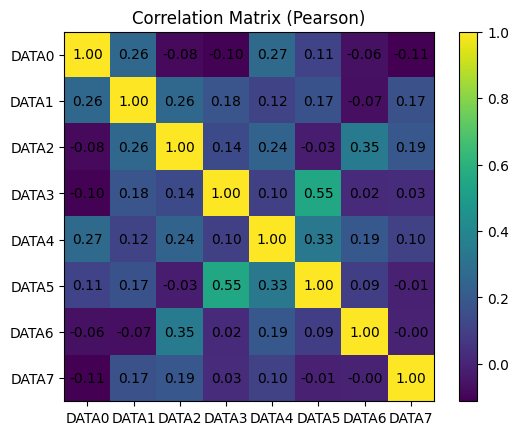

In [21]:
data_cols = [f"DATA{i}" for i in range(8)]
corr_matrix = df[data_cols].corr(method="pearson")

plt.figure()
img = plt.imshow(corr_matrix)
plt.colorbar()

for i in range(len(data_cols)):
    for j in range(len(data_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.xticks(range(len(data_cols)), data_cols)
plt.yticks(range(len(data_cols)), data_cols)
plt.title("Correlation Matrix (Pearson)")

plt.show()

- It is worth noting that `DATA3 ↔ DATA5` are strongly related with correlation of 0.55.
- No severe multicollinearity (nothing above 0.6)
- We can try looking at the correlations at class level to understand the collineraity between DATA3 and DATA5 further.

In [22]:
# Plot separate correlation matrices per class to see if attack traffic
# is driving the DATA3-DATA5 correlation
for label, group in df.groupby("Flag"):
    corr = group[data_cols].corr()
    print(f"\nFlag={label}, DATA3-DATA5 corr: {corr.loc['DATA3','DATA5']:.3f}")


Flag=0, DATA3-DATA5 corr: 0.484

Flag=1, DATA3-DATA5 corr: 0.614

Flag=2, DATA3-DATA5 corr: 0.554


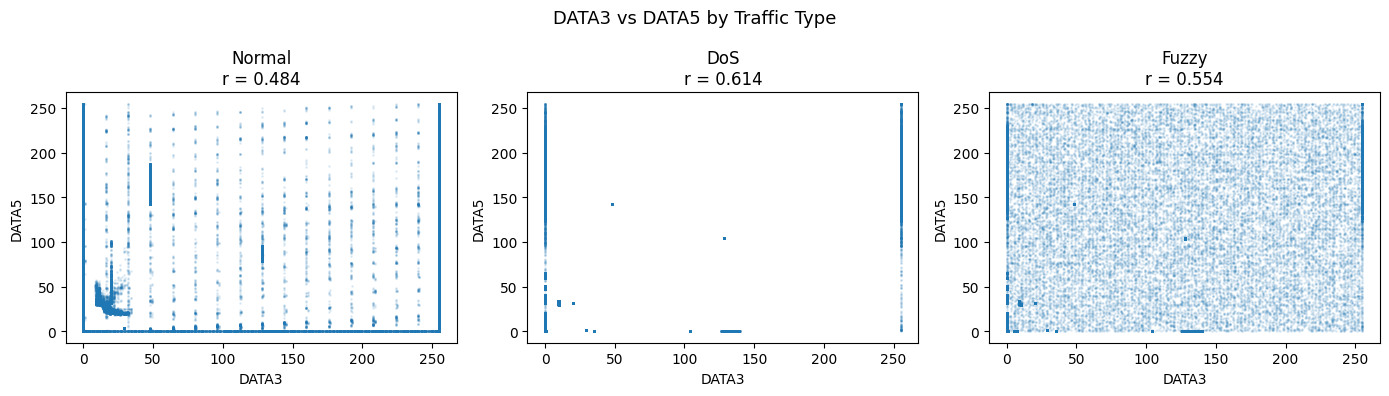

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = {0: "Normal", 1: "DoS", 2: "Fuzzy"}

for ax, (flag, group) in zip(axes, df.groupby("Flag")):
    ax.scatter(group["DATA3"], group["DATA5"], alpha=0.1, s=1)
    ax.set_title(f"{labels[flag]}\nr = {group['DATA3'].corr(group['DATA5']):.3f}")
    ax.set_xlabel("DATA3")
    ax.set_ylabel("DATA5")

plt.suptitle("DATA3 vs DATA5 by Traffic Type", fontsize=13)
plt.tight_layout()
plt.show()

- Normal (r = 0.484) — Rich, structured scatter with many distinct vertical/horizontal bands. This is the fingerprint of real vehicle signals — CAN messages from different ECUs each have their own fixed DATA3/DATA5 patterns, creating these grid-like clusters. Real sensor data has constrained, meaningful values.
- DoS (r = 0.614) — Almost empty! Only a handful of points clustered near (0,0) and at the edges (0, 255) and (255, 0). This is the classic DoS signature — the attacker is flooding the bus with just a few repeated message types, so the data collapses to a tiny set of byte combinations. The high correlation comes from this repetition, not from any real signal relationship.
- Fuzzy (r = 0.554) — Complete uniform noise across the entire 0–255 range. The attacker is randomizing all byte values, which is why it fills the space evenly like static. The residual correlation (0.554) is somewhat surprising given how random it looks — likely driven by the leftover normal traffic mixed in, or the edge concentrations you can see at DATA3=0 and DATA5=0.

**VERDICT:** This correlation could actually be helpful in distinguishing the messages, so you don't need to drop any feature

## Step 5: Train/Test Split

### 5.1 Why Split the Data?

A fundamental rule in machine learning: **never evaluate a model on the data it was trained on**. If you do, you measure how well the model memorized training examples — not how well it generalizes to new, unseen data.

We use a **holdout split**: reserve 30% of data for testing, train on the remaining 70%.

### 5.2 Why Use `stratify=y`?

The dataset is **imbalanced** — normal messages vastly outnumber attack messages (this is realistic: attacks are rare events). Without `stratify=y`, a random split might accidentally place most attack examples in training or test only.

`stratify=y` ensures the **class ratio is preserved** in both the training and test sets, so the model sees a representative proportion of attacks during training and we get a fair evaluation.

> 🔬 **Workshop Challenge:** Before splitting the data, try finding out the proportion of data belonging to each class.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

## Step 6: Model Selection — Random Forest Classifier

A **Random Forest** is an **ensemble learning** method that builds many independent decision trees and combines their predictions by majority voting.

**How it works:**
1. **Bootstrap sampling:** Each tree is trained on a random subset (with replacement) of the training data
2. **Feature randomness:** At each split, only a random subset of features is considered → reduces correlation between trees
3. **Voting:** For classification, the final prediction is the class chosen by the majority of trees

```
                    ┌────────────────────────────────────────┐
   Training Data →  │  Tree 1   Tree 2   Tree 3  ...  Tree N │
                    │    ↓        ↓        ↓            ↓    │
   New Sample  →    │  pred_1  pred_2   pred_3  ...  pred_N  │
                    │              ↓ Majority Vote           │
                    │           Final Prediction             │
                    └────────────────────────────────────────┘
```


> 🔬 **Workshop Challenge:** After completing the notebook, try changing `n_estimators` to 100 or removing `max_depth`. How does performance change? What about training time?

In [25]:
# Define Random Forest classifier
clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=0)

## Step 7: Model training



In [26]:
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=0)

## Step 8: Model Evaluation

After training, we evaluate on the **held-out test set** (data the model has never seen).

We use two complementary metrics:

#### 8.1. Classification Report

For binary classification, the **confusion matrix** has four outcomes:

```
                     Predicted Normal    Predicted Attack
  Actual Normal          TN (correct)        FP (false alarm)
  Actual Attack          FN (missed!)        TP (correct)
```

From these, we compute:

| Metric | Formula | IDS Interpretation |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all messages flagged as attacks, what fraction really were attacks? High precision → few false alarms |
| **Recall** | TP / (TP + FN) | Of all real attacks, what fraction did we catch? High recall → few missed attacks |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall — single balanced metric |
| **Support** | count | Number of samples of each class in the test set |

**Critical tradeoff for security systems:**
> - Low recall (missed attacks) → dangerous: real threats go undetected
> - Low precision (false alarms) → costly: system raises alerts for benign events, causing alert fatigue or unnecessary shutdowns
> - Ideal IDS: maximize both!

#### 8.2. ROC-AUC Score

The **ROC curve** plots True Positive Rate (recall) vs. False Positive Rate at all decision thresholds. The **AUC** (Area Under the Curve) summarizes this:

| AUC Value | Interpretation |
|---|---|
| 1.0 | Perfect classifier |
| 0.9–1.0 | Excellent |
| 0.8–0.9 | Good |
| 0.7–0.8 | Fair |
| 0.5 | Random guessing |
| < 0.5 | Worse than random |

AUC is **threshold-independent** — it measures the model's ability to rank attack messages higher than normal ones regardless of where you set the detection threshold.

> 🔬 **Workshop Challenge:** After completing the notebook, try creating a `confusion matrix` to evaluate your model.

In [27]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"))

Classification Report:
              precision    recall  f1-score   support

           0     0.8300    0.8802    0.8544     60000
           1     0.6880    0.4847    0.5688     60000
           2     0.5803    0.7166    0.6413     60000

    accuracy                         0.6939    180000
   macro avg     0.6994    0.6939    0.6881    180000
weighted avg     0.6994    0.6939    0.6881    180000

ROC AUC: 0.8874790093287036


Congratulations! We have successfully built a ML model for a 3-class CAN bus intrusion detection problem.

Taking a closer look at one test entry

In [30]:
i = 0

print(f"\nFeatures:\n{pd.Series(X_test[i], index=feat_names)}")

print(f"Ground Truth : {y_test.iloc[i]}")
print(f"Predicted    : {y_pred[i]}")



Features:
can_id_int     63
DLC             8
DATA0           3
DATA1          69
DATA2          96
DATA3         255
DATA4         102
DATA5         253
DATA6          12
DATA7           0
dtype: int64
Ground Truth : 0
Predicted    : 0


## Step 9: Interpreting Results

We observed **69.4% overall accuracy and ROC AUC of 0.88**. The AUC is actually quite good meaning that the model ranks attack versus normal traffic well.
 - For Class 0 (Normal), the precision is 0.83 and recall is 0.88. This means that the model is good at identifying the normal traffic.
 - For Class 1 (DoS attack), the recall is only 0.48. This means that the model misses nearly 52% of these attacks.
 - For Class 2 (Fuzzy attack), the recall is moderate (0.72) but the precision 0.58 indicates many false alarms.

### What the low recall on Class 1 likely means?

- Class 1 attacks may look very similar to normal traffic in your feature space

- The hex DATA bytes might not carry enough signal for this attack type



### Before you go, think about the following questions:

- Now that we have trained our model on DoS and Fuzzy attack types, will this model generalize well on novel attack type like spoofing attacks?
- How would you modify this pipeline to detect spoofing attacks?
- Would adding additional features improve or worsen the model?
- Why might Recall be more important than Precision in a vechicle IDS?

## ⏱️ Estimated Time: 60–90 minutes